<a href="https://colab.research.google.com/github/ALDO12062004/EDP2/blob/main/M%C3%A9tododeGalerkin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MÉTODO DE GALERKIN

Se debe encontrar una solución aproximada a $$-u''+u-x=0$$ con las condiciones de frontera $$u(0)=u(1)=0$$ usando el método de Galerkin.

Use

$$u_3=\sum_{i=1}^3 \alpha_i \beta_i(x)$$

con $$\beta_i(x)=\sin(i\pi x)$$ para encontrar las constantes apropiadas $$\alpha_i$$


---
***Solución***

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

Se importan las librerias Sympy para cálculo simbólico, numpy para convertir a un arreglo y matplotlib para graficar

Solución de la EDO
$$-u′′+u-x=0$$

con

$$u(0)=u(1)=0$$

In [ ]:
x, a, b, c= sp.symbols('x a b c') #introducimos 4 variables que se utilizarán más adelante
u = sp.Function('u') #esto es una función

Se define una variable y una función para plantear y darle solución a la EDO

In [ ]:
ode = -u(x).diff(x,x) + u(x) - x #Es la edo planteada
sp.dsolve(ode,u(x)) #Resuelve la EDO

Eq(u(x), C1*exp(-x) + C2*exp(x) + x)

Se plantea y resuelve la EDO

In [ ]:
sol = sp.dsolve(ode, ics={u(0):0, u(1):0}) #ics es una estructura de diccionario
sol

Eq(u(x), x - E*exp(x)/(-1 + exp(2)) + E*exp(-x)/(-1 + exp(2)))

Se introducen las condiciones iniciales para obtener una solución especifica

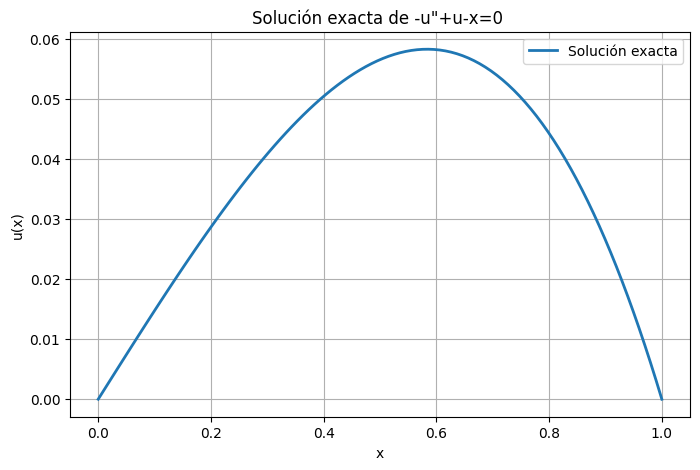

In [ ]:
# convertimos en un arreglo
u_expr = sol.rhs

u_num = sp.lambdify(x,u_expr,"numpy")

xx = np.linspace(0,1,100)
yy = u_num(xx)

plt.figure(figsize=(8,5))
plt.plot(xx, yy, label=f'Solución exacta', linewidth=2)
plt.title('Solución exacta de -u"+u-x=0 ')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.grid(True)
plt.show()

Gráfica de la solución exacta de la EDO en el intervalo [0,1]

#Solución numérica

Se propone una solución de la forma:

$$u_3=\alpha_1\sin(\pi x)+\alpha_2\sin(2\pi x) + \alpha_3\sin(3\pi x)$$

In [ ]:
u_3 = a*sp.sin(sp.pi*x) + b*sp.sin(2*sp.pi*x) + c*sp.sin(3*sp.pi*x)
u_3

a*sin(pi*x) + b*sin(2*pi*x) + c*sin(3*pi*x)

Solución propuesta

In [ ]:
u_n_3 = sp.diff(u_3,x,2) #deriva dos veces con respecto de x a u_n

E = -u_n_3 + u_3 - x  #Se plantea el error

E

a*sin(pi*x) + b*sin(2*pi*x) + c*sin(3*pi*x) - x + pi**2*(a*sin(pi*x) + 4*b*sin(2*pi*x) + 9*c*sin(3*pi*x))

Se define el error en base a la solución propuesta

In [ ]:
I_1= sp.integrate(E*sp.sin(sp.pi*x),(x,0,1))
I_2= sp.integrate(E*sp.sin(2*sp.pi*x),(x,0,1))
I_3= sp.integrate(E*sp.sin(3*sp.pi*x),(x,0,1))

Se aplica el método de galerkin donde el criterio es:

$$I_1=\int_0^1 E\sin(\pi x) dx=0$$

$$I_2=\int_0^1 E\sin(2\pi x) dx=0$$

$$I_3=\int_0^1 E\sin(3\pi x) dx=0$$


In [ ]:
I_1

a/2 + pi**2*a/2 - 1/pi

Resultado de la integral 1

In [ ]:
I_2

b/2 + 2*pi**2*b + 1/(2*pi)

Resultado de la integral 2

In [ ]:
I_3

c/2 + 9*pi**2*c/2 - 1/(3*pi)

Resultado de la integral 3

De los resultados de las integrales se obtiene un sistema de ecuaciones

In [ ]:
soleq = sp.solve([I_1,I_2,I_3],[a,b,c], simplify=True) #Resuelve el sistema de ecuaciones respecto de a,b y c

Del sistema obtenido de las 3 integrales se resuelve para obtener los coeficientes de a, b y c

In [ ]:
soleq

{a: 2/(pi + pi**3), b: -1/(pi + 4*pi**3), c: 2/(3*pi + 27*pi**3)}

Coeficientes de a, b y c

In [ ]:
u_approx=u_3.subs(soleq) #Sustituye valores en u_3

Se sustituyen los coeficientes obtenidos en la solución propuesta $u_3$

In [ ]:
u_approx

2*sin(pi*x)/(pi + pi**3) - sin(2*pi*x)/(pi + 4*pi**3) + 2*sin(3*pi*x)/(3*pi + 27*pi**3)

Solución aproximada con el método de galerkin

In [ ]:
u_approx_fn = sp.lambdify(x,u_approx,"numpy") #Convierte a un arreglo numpy para poder graficar

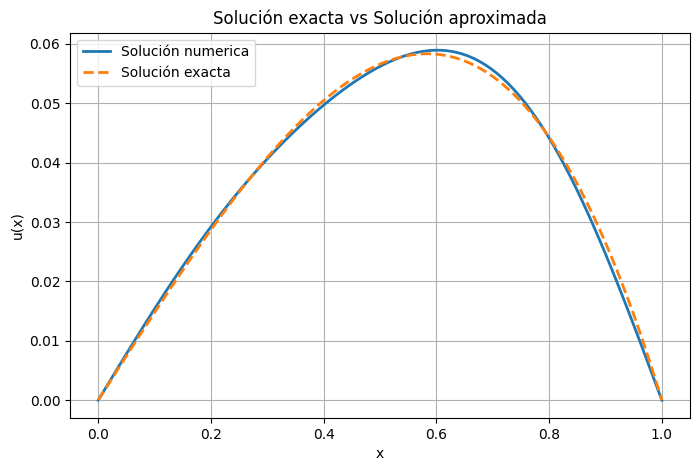

In [ ]:
xx = np.linspace(0,1,100)

plt.figure(figsize=(8,5))
plt.plot(xx, u_approx_fn(xx), label=f'Solución numerica', linewidth=2)
plt.plot(xx, yy,"--" ,label=f'Solución exacta', linewidth=2)
plt.title('Solución exacta vs Solución aproximada')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.grid(True)
plt.show()

Gráfica de la solución exacta vs la solución aproximada.
El error es pequeño, ambas graficas son muy parecidas "casi iguales", pero no estan del todo sobrepuestas, pero la aproximación de $u_3$ es bastante buena

#Error de la solución numérica

Se usó el error puntual o absoluto

$$E(x)=u(x)-u_N(x)$$


Es decir, en cada punto $x$ la diferencia entre la solución exacta y la aproximación.

In [ ]:
# solución exacta
u_exact = u_expr

# solución numérica
u_N = u_approx

# error simbólico
E = sp.simplify(u_exact - u_N)
sp.simplify(E)

x + E*exp(x)/(1 - exp(2)) - 2*sin(pi*x)/(pi + pi**3) + sin(2*pi*x)/(pi + 4*pi**3) - 2*sin(3*pi*x)/(3*pi + 27*pi**3) - E*exp(-x)/(1 - exp(2))

Este es el error "general" de la función, solo bastaría seleccionar un punto y evaluar en $E(x)$ para obtener una representación numérica del error en dicho punto ya que no se especifica en que puntos evaluar, por lo que esto funciona para cualquier punto en el intervalo [0,1]